<a href="https://colab.research.google.com/github/bavinkdevadas-hub/ML-Projects/blob/main/Heart%20Attack%20Risk%20Prediction/Heart_Attack_Risk_Prediction_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Problem statement

With HadHeartAttack as the prediction variable, the task would involve using other features in the dataset to predict whether a patient has experienced a heart attack. This could be approached as a binary classification problem, where the model learns patterns from the other variables to predict the likelihood of HadHeartAttack (0 for no, 1 for yes).


Heart disease is one of the leading causes of mortality worldwide, with heart attacks being a primary manifestation. Early detection and intervention can significantly reduce the risk and improve patient outcomes. In this project, we aim to develop a predictive model that leverages patient demographic, health, and lifestyle information to determine the likelihood of a heart attack occurrence. By analyzing this data, healthcare providers may gain insights into high-risk patients, enabling proactive measures and better allocation of medical resources.

The objective is to predict whether a patient has had a heart attack (binary outcome: HadHeartAttack) based on a range of features, including medical history, lifestyle habits, and demographic details. This model could serve as an assistive tool in clinical decision-making and help in implementing preventive healthcare strategies.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset/Patients Data ( Used for Heart Disease Prediction ).csv")
df


,PatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1,"Black only, Non-Hispanic",0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237625,237626,Puerto Rico,Female,Good,Age 60 to 64,1.57,90.720001,36.580002,0,0,...,Not at all (right now),0,Hispanic,0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
237626,237627,Puerto Rico,Female,Good,Age 55 to 59,1.70,72.570000,25.059999,0,1,...,Not at all (right now),0,Hispanic,0,1,0,0,"Yes, received Tdap",0,0
237627,237628,Puerto Rico,Male,Fair,Age 45 to 49,1.75,70.309998,22.889999,1,1,...,Not at all (right now),1,Hispanic,0,1,1,1,"Yes, received Tdap",1,0
237628,237629,Puerto Rico,Female,Very good,Age 25 to 29,1.57,46.720001,18.840000,0,0,...,Never used e-cigarettes in my entire life,0,Hispanic,0,1,0,0,"No, did not receive any tetanus shot in the pa...",0,1


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   PatientID                  237630 non-null  int64  
 1   State                      237630 non-null  object 
 2   Sex                        237630 non-null  object 
 3   GeneralHealth              237630 non-null  object 
 4   AgeCategory                237630 non-null  object 
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [ ]:
df.isnull().sum()

,0
PatientID,0
State,0
Sex,0
GeneralHealth,0
AgeCategory,0
HeightInMeters,0
WeightInKilograms,0
BMI,0
HadHeartAttack,0
HadAngina,0


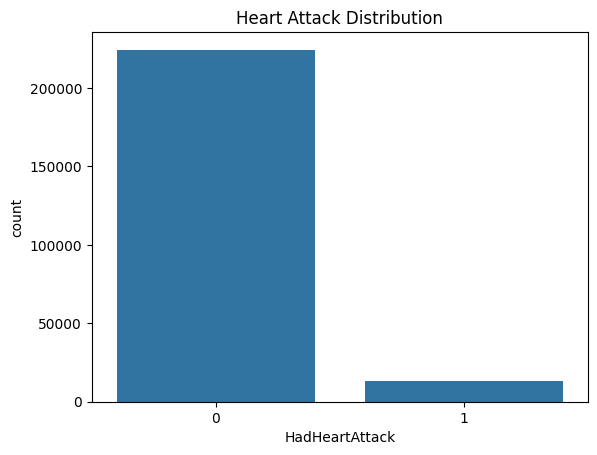

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='HadHeartAttack', data=df)
plt.title('Heart Attack Distribution')
plt.show()

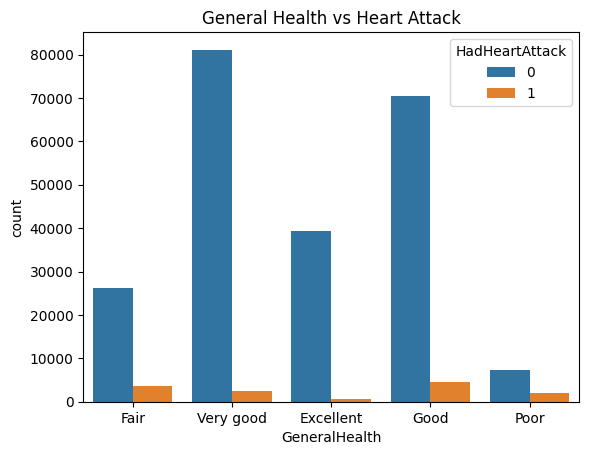

In [ ]:
sns.countplot(x='GeneralHealth', hue='HadHeartAttack', data=df)
plt.title('General Health vs Heart Attack')
plt.show()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop(["PatientID"],axis=1,inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   State                      237630 non-null  object 
 1   Sex                        237630 non-null  object 
 2   GeneralHealth              237630 non-null  object 
 3   AgeCategory                237630 non-null  object 
 4   HeightInMeters             237630 non-null  float64
 5   WeightInKilograms          237630 non-null  float64
 6   BMI                        237630 non-null  float64
 7   HadHeartAttack             237630 non-null  int64  
 8   HadAngina                  237630 non-null  int64  
 9   HadStroke                  237630 non-null  int64  
 10  HadAsthma                  237630 non-null  int64  
 11  HadSkinCancer              237630 non-null  int64  
 12  HadCOPD                    237630 non-null  int64  
 13  HadDepressiveDisorder      23

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["Sex"]=le.fit_transform(df["Sex"])

In [ ]:
# Step 2: Ordinal Encoding (Preserving Logical Rank)
# ---------------------------------------------------------
health_map = {
    'Poor': 0,
    'Fair': 1,
    'Good': 2,
    'Very good': 3,
    'Excellent': 4
}

age_map = {
    'Age 18 to 24': 0, 'Age 25 to 29': 1, 'Age 30 to 34': 2, 'Age 35 to 39': 3,
    'Age 40 to 44': 4, 'Age 45 to 49': 5, 'Age 50 to 54': 6, 'Age 55 to 59': 7,
    'Age 60 to 64': 8, 'Age 65 to 69': 9, 'Age 70 to 74': 10, 'Age 75 to 79': 11,
    'Age 80 or older': 12
}

smoker_map = {
    'Never smoked': 0,
    'Former smoker': 1,
    'Current smoker - now smokes some days': 2,
    'Current smoker - now smokes every day': 3
}

ecig_map = {
    'Never used e-cigarettes in my entire life': 0,
    'Not at all (right now)': 1,
    'Use them some days': 2,
    'Use them every day': 3
}

# Apply mappings
df['GeneralHealth'] = df['GeneralHealth'].map(health_map)
df['AgeCategory'] = df['AgeCategory'].map(age_map)
df['SmokerStatus'] = df['SmokerStatus'].map(smoker_map)
df['ECigaretteUsage'] = df['ECigaretteUsage'].map(ecig_map)

In [ ]:
# List of nominal columns
nominal_cols = ['State', 'RaceEthnicityCategory', 'HadDiabetes', 'TetanusLast10Tdap']

# Replace string categories with numerical codes (0, 1, 2, 3...)
for col in nominal_cols:
    df[col] = df[col].astype('category').cat.codes

In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# Separate features and target
x = df.drop(columns=['HadHeartAttack'])
y = df['HadHeartAttack']

# Apply SMOTE
smote = SMOTE(random_state=42)
x_res, y_res = smote.fit_resample(x, y)

# Combine into one DataFrame
df_smote = pd.DataFrame(x_res, columns=x.columns)
df_smote['HadHeartAttack'] = y_res

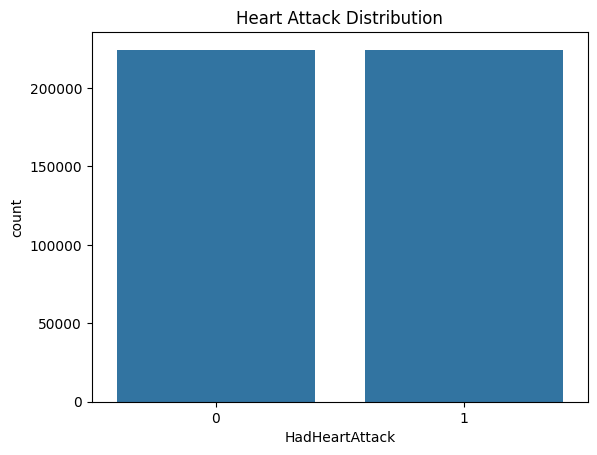

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='HadHeartAttack', data=df_smote)
plt.title('Heart Attack Distribution')
plt.show()

In [ ]:
df=df_smote

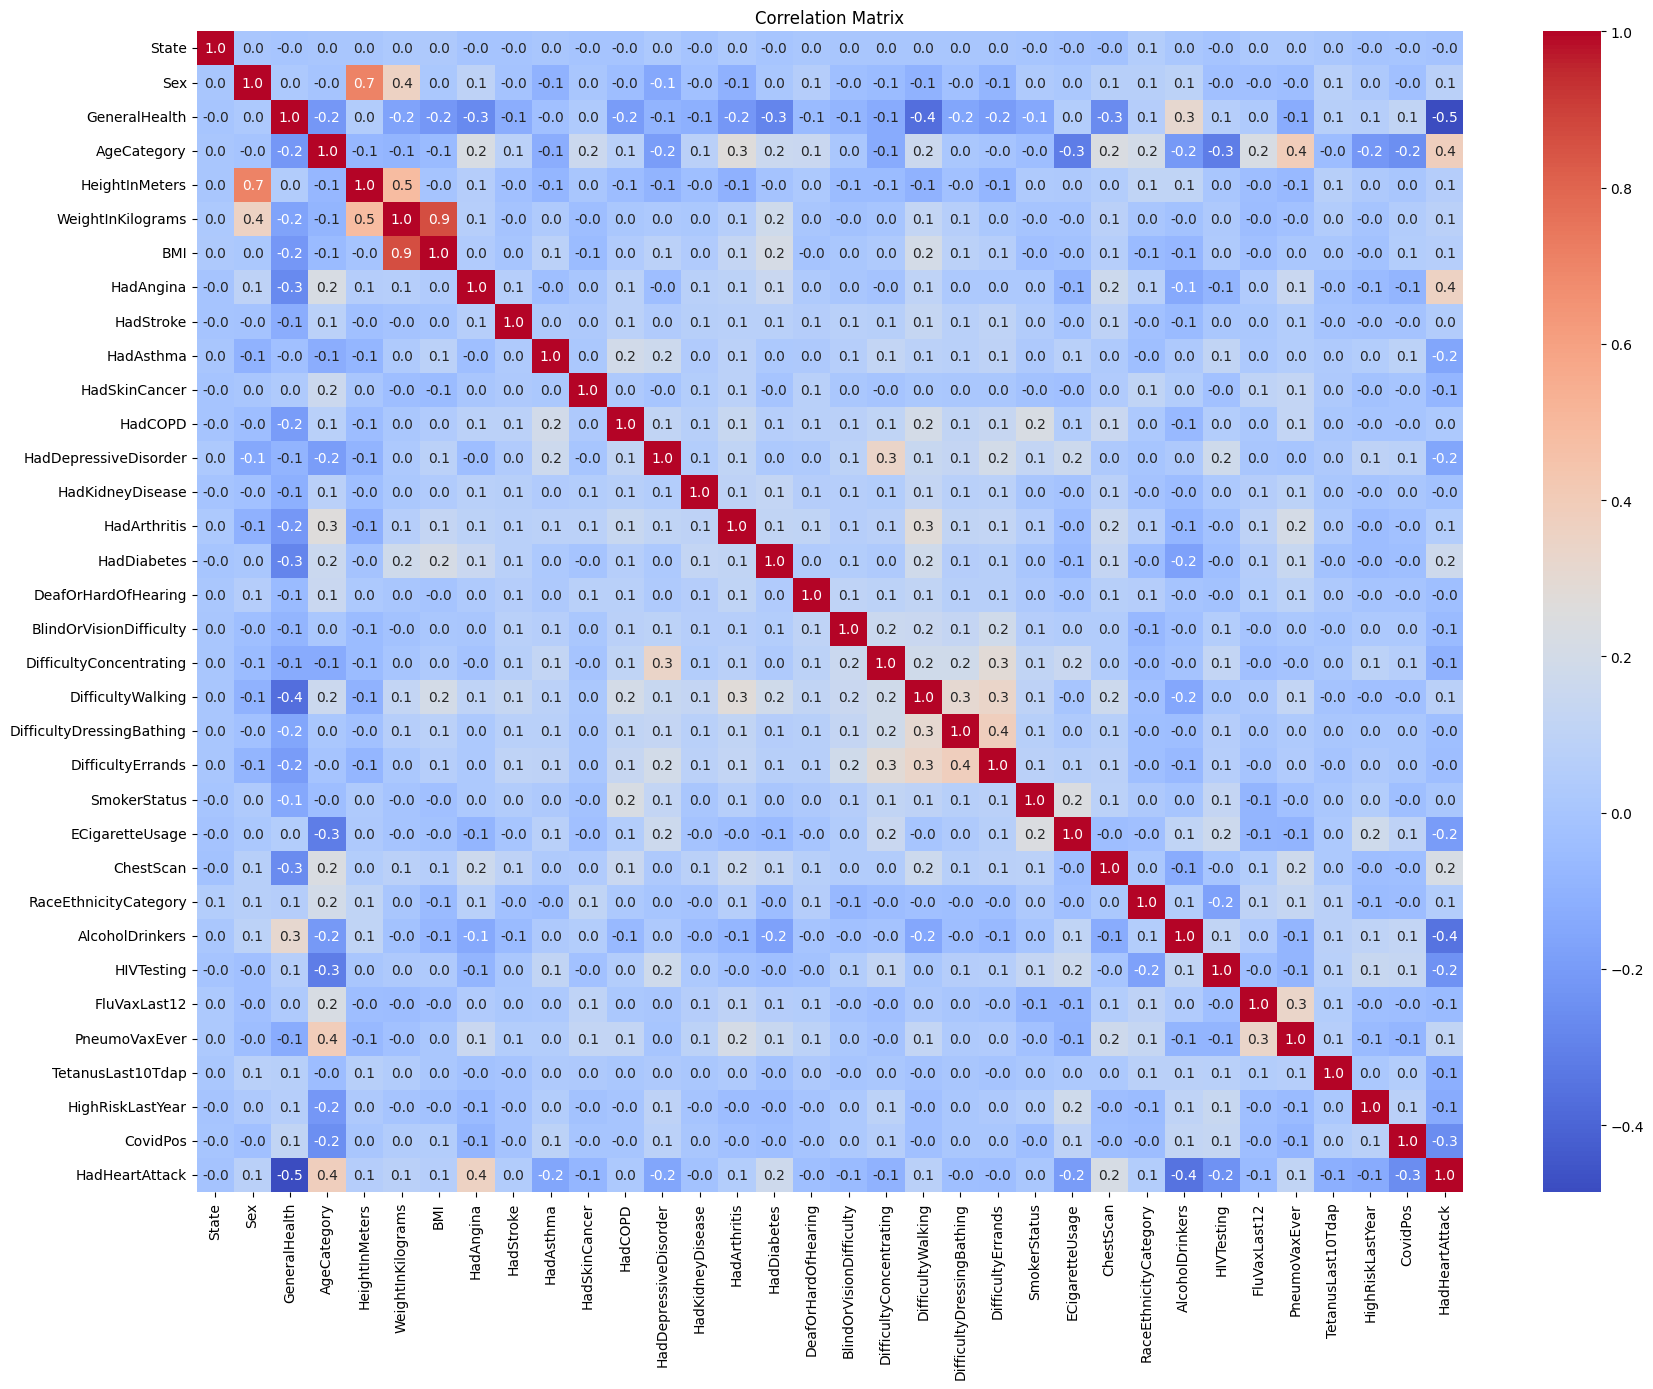

In [ ]:
# Correlation matrix
corr_matrix=df.corr()
# Heatmap of correlation matrix
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix,annot=True,fmt="0.01f",cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [ ]:
df


,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadAngina,HadStroke,HadAsthma,...,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,HadHeartAttack
0,0,0,1,11,1.630000,84.820000,32.099998,1,0,1,...,1,4,0,0,0,1,0,0,1,0
1,0,0,3,9,1.600000,71.669998,27.990000,0,0,0,...,0,4,0,0,1,1,1,0,0,0
2,0,1,4,8,1.780000,71.209999,22.530001,0,0,0,...,0,4,1,0,0,0,2,0,0,0
3,0,1,3,10,1.780000,95.250000,30.129999,0,0,0,...,0,4,0,0,1,1,2,0,0,0
4,0,0,2,6,1.680000,78.019997,27.760000,0,0,0,...,1,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
448853,7,0,0,7,1.717087,120.199997,40.810817,1,0,0,...,1,4,0,0,0,0,0,0,1,1
448854,27,0,1,8,1.544282,78.861586,33.058564,0,0,0,...,0,4,0,0,0,0,0,0,0,1
448855,50,0,1,5,1.690454,74.839996,26.308008,0,0,0,...,1,4,1,0,0,0,1,0,0,1
448856,27,0,0,5,1.611377,104.330002,40.262166,0,0,0,...,1,4,0,0,1,1,1,0,0,1


In [ ]:
df = df.drop(columns=['WeightInKilograms', 'HeightInMeters'])

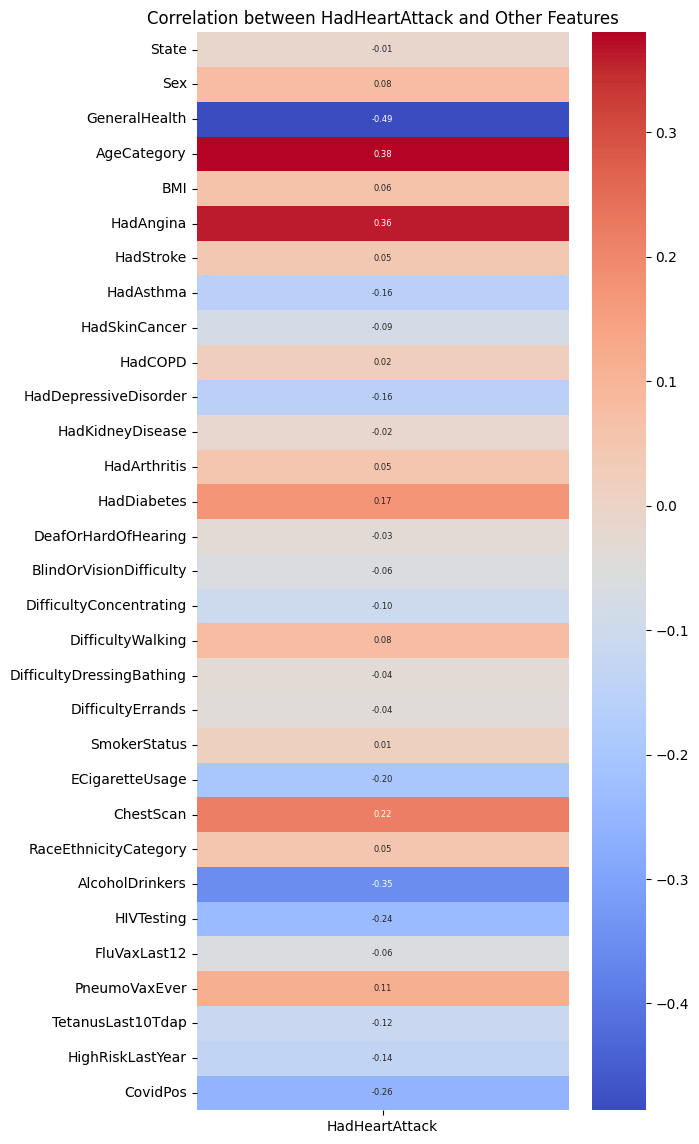

In [ ]:
# Calculate the correlation between 'HadHeartAttack' and all other columns
loan_status_corr=df.corr()['HadHeartAttack']

# Remove the correlation of 'HadHeartAttack'with itself (which is always 1)
loan_status_corr=loan_status_corr.drop('HadHeartAttack')
# Create a heatmap to visualize the correlations
plt.figure(figsize=(6, 14))
sns.heatmap(loan_status_corr.to_frame(),annot=True,fmt='.2f',cmap='coolwarm',
            cbar=True,annot_kws={'size':6}) # to_frame() converts Series to DataFrame for heatmap
plt.title('Correlation between HadHeartAttack and Other Features')
plt.show()

In [ ]:
df = df.drop(columns=[
    'State',
    'HadAsthma',
    'HadDepressiveDisorder',
    'ECigaretteUsage',
    'HIVTesting',
    'TetanusLast10Tdap',
    'HighRiskLastYear',
    'CovidPos'
])

In [ ]:
df

,Sex,GeneralHealth,AgeCategory,BMI,HadAngina,HadStroke,HadSkinCancer,HadCOPD,HadKidneyDisease,HadArthritis,...,DifficultyWalking,DifficultyDressingBathing,DifficultyErrands,SmokerStatus,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,FluVaxLast12,PneumoVaxEver,HadHeartAttack
0,0,1,11,32.099998,1,0,1,0,0,1,...,1,0,0,1,1,4,0,0,1,0
1,0,3,9,27.990000,0,0,0,0,0,1,...,0,0,0,1,0,4,0,1,1,0
2,1,4,8,22.530001,0,0,0,0,0,0,...,0,0,0,0,0,4,1,0,0,0
3,1,3,10,30.129999,0,0,0,0,0,1,...,0,0,0,1,0,4,0,1,1,0
4,0,2,6,27.760000,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
448853,0,0,7,40.810817,1,0,0,1,0,1,...,1,0,1,0,1,4,0,0,0,1
448854,0,1,8,33.058564,0,0,0,0,0,1,...,0,0,0,3,0,4,0,0,0,1
448855,0,1,5,26.308008,0,0,0,0,0,0,...,0,0,0,1,1,4,1,0,0,1
448856,0,0,5,40.262166,0,0,0,0,0,0,...,0,0,0,1,1,4,0,1,1,1


<Axes: >

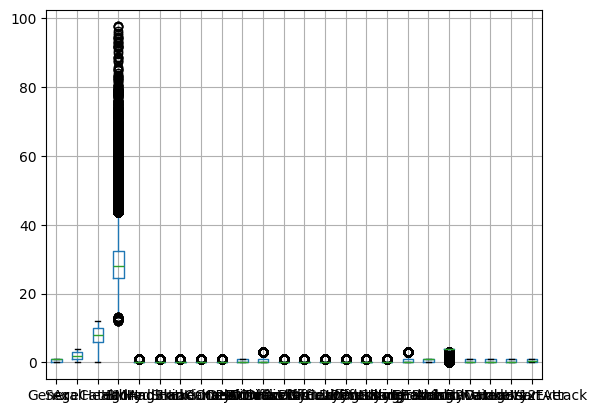

In [ ]:
df.boxplot()

In [ ]:
# Function to remove outliers using the IQR method except for one column
def remove_outliers_iqr(df,exclude_column):


  for col in df.columns:

   # Skip the specified column
    if col==exclude_column:
      continue
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    # Filter the DataFrame to remove rows with outliers in each column
    df=df[(df[col]>=lower_bound)&(df[col]<=upper_bound)]
  return df


# Specify the column to exclude
df_cleaned=remove_outliers_iqr(df,exclude_column="HadHeartAttack")
df=df_cleaned

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
 #Select the features that you want to scale
features = [
    'Sex',
    'GeneralHealth',
    'AgeCategory',
    'BMI',
    'HadAngina',
    'HadStroke',
    'HadSkinCancer',
    'HadCOPD',
    'HadKidneyDisease',
    'DifficultyConcentrating',
    'DifficultyWalking',
    'DifficultyDressingBathing',
    'DifficultyErrands',
    'SmokerStatus',
    'ChestScan',
    'RaceEthnicityCategory',
    'AlcoholDrinkers',
    'FluVaxLast12',
    'PneumoVaxEver'
]
# Create a MinMaxScaler object
scaler = MinMaxScaler()
# Fit the scaler to your data and transform it
scaled_data = scaler.fit_transform(df[features])
# Create a DataFrame from scaled_data with the correct column names
scaled_df=pd.DataFrame(scaled_data,columns=features)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

x=scaled_df
y=df["HadHeartAttack"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
# Train a baseline logistic regression model
model=LogisticRegression()
model.fit(x_train,y_train)
# Predict and evaluate the model
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(f"baseline model accuracy:{accuracy:.2f}")

baseline model accuracy:0.83


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(x_train,y_train)
pred=model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8526426321316066


In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(x_train,y_train)
pred=model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8672266946680668


In [ ]:
from xgboost import XGBClassifier
model=XGBClassifier()
model.fit(x_train,y_train)
pred=model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8589429471473574


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
model=AdaBoostClassifier()
model.fit(x_train,y_train)
pred=model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8288706101971766


In [ ]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression()
#track best fold data
best_accuracy=0
best_fold=-1

# Save best fold's data
best_x_train = None
best_y_train = None
best_x_test = None
best_y_test = None
best_y_pred = None

# Loop over each fold
for fold, (train_index, test_index) in enumerate(kf.split(x), 1):
    x_train, x_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train model
    model.fit(x_train, y_train)

    # Predict
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Fold {fold} Accuracy: {acc}")

    # Update best fold
    if acc > best_accuracy:
      best_accuracy = acc
      best_fold = fold
      best_x_train = x_train
      best_y_train = y_train
      best_x_test = x_test
      best_y_test = y_test
      best_y_pred = y_pred
 # Output best fold details
print(f"\n Best Fold: {best_fold} with Accuracy: {best_accuracy}")

Fold 1 Accuracy: 0.8300215116491049
Fold 2 Accuracy: 0.8265577715389945
Fold 3 Accuracy: 0.8248076712728334
Fold 4 Accuracy: 0.8256827214059139
Fold 5 Accuracy: 0.8279432675830386

 Best Fold: 1 with Accuracy: 0.8300215116491049


In [ ]:
model = LogisticRegression()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.8300215116491049

In [ ]:
model=DecisionTreeClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.856528238597003

In [ ]:
model=RandomForestClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.8709301053706202

In [ ]:
model=XGBClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.8596638349072082

In [ ]:
model=AdaBoostClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.8310059430488205

In [ ]:
from sklearn.svm import SVC
model=SVC()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.8341779997812374

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
# Defining the ANN model
model = Sequential()
model.add(Dense(64, input_shape=(19,),activation='relu'))  # Hidden Layer 1
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))               # Hidden Layer 2
model.add(Dense(1, activation='sigmoid'))             # Output Layer

# Compiling the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Training the model
model.fit(best_x_train, best_y_train, epochs=40, batch_size=32)

Epoch 1/40
3429/3429 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.8232 - loss: 0.3893
Epoch 2/40
3429/3429 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8276 - loss: 0.3785
Epoch 3/40
3429/3429 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8288 - loss: 0.3762
Epoch 4/40
3429/3429 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.8299 - loss: 0.3746
Epoch 5/40
3429/3429 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8300 - loss: 0.3734
Epoch 6/40
3429/3429 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8303 - loss: 0.3724
Epoch 7/40
3429/3429 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8318 - loss: 0.3716
Epoch 8/40
3429/3429 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8317 - loss: 0.3709
Epoch 9/40
3429/3429 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8326 - loss: 0.3696
Epoch 10/40
3429/3429 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8323 - loss: 0.3690
Epoch 11/40
3429/3429 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8330 - loss: 0.3682
Epoch 12/40
3429/3429

In [ ]:
# Evaluating the model
loss, accuracy = model.evaluate( best_x_test, best_y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

858/858 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8407 - loss: 0.3521
Model Accuracy: 84.07%


## Conclusion

This project successfully applied machine learning techniques to predict heart disease using patient health data. Data preprocessing, exploratory analysis, and SMOTE were used to handle the class imbalance and improve the model's ability to identify heart attack cases. Several machine learning models were evaluated, including Decision Tree, Random Forest, XGBoost, and AdaBoost.

Among the models tested, **Random Forest achieved the highest accuracy of 86.73%**, followed by XGBoost (85.89%), Decision Tree (85.29%), and AdaBoost (82.89%). The K-Fold cross-validation achieved an accuracy of approximately **83.95%**, providing additional validation of the model's performance. Based on these results, Random Forest was selected as the best-performing model for this heart disease prediction project.
